In [2]:
import matplotlib, numpy, pandas, scipy, shapely, networkx, astropy, aplpy, lmfit

print("matplotlib", matplotlib.__version__ , '3.7.5')
print("numpy", numpy.__version__, '1.24.4')
print("pandas", pandas.__version__, '2.0.3')
print("scipy", scipy.__version__, '1.6.0')
print("shapely", shapely.__version__, '2.0.3')
print("networkx", networkx.__version__, '3.1')
print("astropy", astropy.__version__, '5.2.2')
print("aplpy", aplpy.__version__, '2.1.0')
print("lmfit", lmfit.__version__, '1.2.2')

matplotlib 3.10.8 3.7.5
numpy 2.4.4 1.24.4
pandas 3.0.2 2.0.3
scipy 1.17.1 1.6.0
shapely 2.1.2 2.0.3
networkx 3.6.1 3.1
astropy 7.2.0 5.2.2
aplpy 2.2.0 2.1.0
lmfit 1.3.4 1.2.2


In [7]:
from analysis import analyse, load, plotter
from analysis import polygons_utility as putility
from analysis import network_utility as utility

import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.dpi'] = 150 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from pathlib import Path
import pandas as pd

path = Path("./benchmark/config/").resolve()

reader = lambda x: pd.read_csv(x, delimiter=",", comment="#")

dataset = analyse.DataSet(
    analyse.Data(config, reader_to_df=reader)
    for config in path.glob("*.toml")
)

for name, data in dataset.items():
    print(f"sample {name} : {len(data.df)} elements")
    
print(f"total #elements = {sum(data.df.size for data in dataset)}")

sample L01 : 12 elements
sample L02 : 12 elements
sample L03 : 14 elements
sample L04 : 17 elements
sample L05 : 19 elements
total #elements = 518


# Attributes of Data class

- 'path': path of the config file that is used to read the data
- 'df': normalised dataframe the code reads
- 'comment': any comment in the config file
- 'catalog': origin of catalog file
- 'fits_img': fits image from which the objects are extracted
- 'beam': observation beam (in arcsec)
- 'wavelength': wavelenght of observation (in µm)
- 'distance': distance of the region (in pc)
- 'fov_window': polygon object that define the field of view of extraction (-1 if all image is used)
- 'color': color used to represent the data in the figures

In [46]:
print(network)

Network
min_overlap - 0.75
n_nodes - 74
n_edges - 77
n_components - 10
levels - (0.0625, 0.125, 0.25, 0.5, 1.0)


In [45]:
network = analyse.Network(dataset, min_overlap=0.75)

clumps = utility.toDataFrame(network.network)

network.extractStructures()
structure_table = network.getStructuresTable()

In [21]:
print(clumps.columns)
clumps

Index(['_Y', '_beam', '_A', '_level', '_X', '_B', '_Theta', '_R', '_Kind',
       '_Fractality', '_Polygon', '_Holes'],
      dtype='str')


,_Y,_beam,_A,_level,_X,_B,_Theta,_R,_Kind,_Fractality,_Polygon,_Holes
0,-8.976751,0.0625,0.349059,0,-1.750423,0.299280,2.868955,1163.564086,NodeKind.SINK,None,POLYGON ((-2.08658849193883 -8.882758692888459...,0
1,5.127945,0.0625,0.381910,0,6.363394,0.301329,1.592471,1221.246594,NodeKind.SINK,None,"POLYGON ((6.355116666275062 5.509765275487186,...",0
2,-1.034597,0.0625,0.311934,0,4.049875,0.228361,-0.821542,960.827143,NodeKind.SINK,None,POLYGON ((4.262331323921199 -1.262994358897292...,0
3,-5.193165,0.0625,0.386918,0,6.945946,0.316065,1.933002,1258.925572,NodeKind.SINK,None,"POLYGON ((6.80884635052061 -4.831351514976019,...",0
4,-6.740059,0.0625,0.305581,0,5.807902,0.237777,2.437695,970.398743,NodeKind.SINK,None,POLYGON ((5.574950514363674 -6.542288728543264...,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69,2.187678,1.0000,1.632452,4,2.127991,1.344487,1.238741,5333.362611,NodeKind.SOURCE,[1.0],"POLYGON ((2.660148844341113 3.73095646984706, ...",0
70,-2.759121,1.0000,1.374163,4,-7.982926,1.025020,0.983765,4272.556094,NodeKind.SOURCE,[1.0912806233094392],POLYGON ((-7.221788351547324 -1.61500755918036...,0
71,-1.752286,1.0000,1.343551,4,-7.973582,0.995508,2.423373,4163.435099,NodeKind.SOURCE,[1.1689595163588151],POLYGON ((-8.985246860790676 -0.86816928453392...,0
72,-2.596891,1.0000,2.007738,4,0.949390,1.580785,-0.829305,6413.461040,NodeKind.SOURCE,[1.0],POLYGON ((2.3053929718240775 -4.07752226391344...,0


In [11]:
structure_table

,component,sinks,sources,mode,fractality,missed,percmissed,maxR,YSO,gas,polygon,size,xposition,yposition
0,"(0, 36, 50, 19, 62)",1,1,LINEAR,1.000000,0,0.00,1.0,0,3,POLYGON ((-1.3079204472403945 -7.5488219313371...,2.493013,-1.392199,-9.066496
1,"(1, 37, 51, 20, 63)",1,1,LINEAR,1.000000,0,0.00,1.0,0,3,"POLYGON ((5.182937500979292 6.70347648086091, ...",2.824382,5.903552,5.190801
2,"(64, 2, 38, 52, 21)",1,1,LINEAR,1.000000,0,0.00,1.0,0,3,POLYGON ((3.6235491613387887 0.136167070051093...,2.618336,4.353962,-1.190942
3,"(65, 3, 39, 53, 22)",1,1,LINEAR,1.000000,0,0.00,1.0,0,3,POLYGON ((8.005969049058784 -6.375065207960578...,2.598091,7.061455,-4.891410
4,"(66, 4, 40, 54, 23)",1,1,LINEAR,1.000000,0,0.00,1.0,0,3,"POLYGON ((6.42163429816917 -7.915677995894772,...",2.442545,5.630147,-6.706865
5,"(67, 68, 5, 6, 7, 8, 41, 10, 42, 43, 9, 56, 55...",6,2,HIERARCHICAL,1.479549,7,0.28,1.0,0,10,POLYGON ((8.253847743696411 -3.706019147797537...,3.252109,9.280162,-2.411275
6,"(69, 11, 44, 57, 29)",1,1,LINEAR,1.000000,0,0.00,1.0,0,3,"POLYGON ((2.72235554873071 3.707393300589287, ...",2.625336,2.127991,2.187678
7,"(32, 70, 71, 12, 45, 14, 13, 46, 58, 59, 30, 31)",3,2,HIERARCHICAL,1.130120,3,0.20,1.0,0,7,POLYGON ((-7.128593516256042 -3.35328924355578...,2.581457,-8.047485,-2.307263
8,"(33, 72, 15, 47, 60)",1,1,LINEAR,1.000000,0,0.00,1.0,0,3,POLYGON ((2.2460821431277105 -4.12850955118860...,3.157013,0.949390,-2.596891
9,"(34, 35, 73, 16, 17, 18, 48, 49, 61)",3,1,HIERARCHICAL,1.297526,0,0.00,1.0,0,5,POLYGON ((-7.143998107590339 10.75716161048234...,2.102721,-7.407338,9.367358


In [ ]:
suspicious = np.array([1, 2, 3, 10, 11, 17, 18, 20, 22]) - 1
#not_suspicious = np.array([4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23]) - 1

hierarchical_structures = structure_table.loc[structure_table["mode"] == "HIERARCHICAL", "component"]

#4 also but particular

hierarchical_structures[~hierarchical_structures.index.isin(hierarchical_structures.index[suspicious])]

to_consider = structure_table[~structure_table.index.isin(hierarchical_structures.index[suspicious])]
to_consider.index = np.arange(0, len(to_consider))

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


INFO: Auto-setting vmin to  3.747e-34 [aplpy.core]
INFO: Auto-setting vmax to  4.464e+01 [aplpy.core]


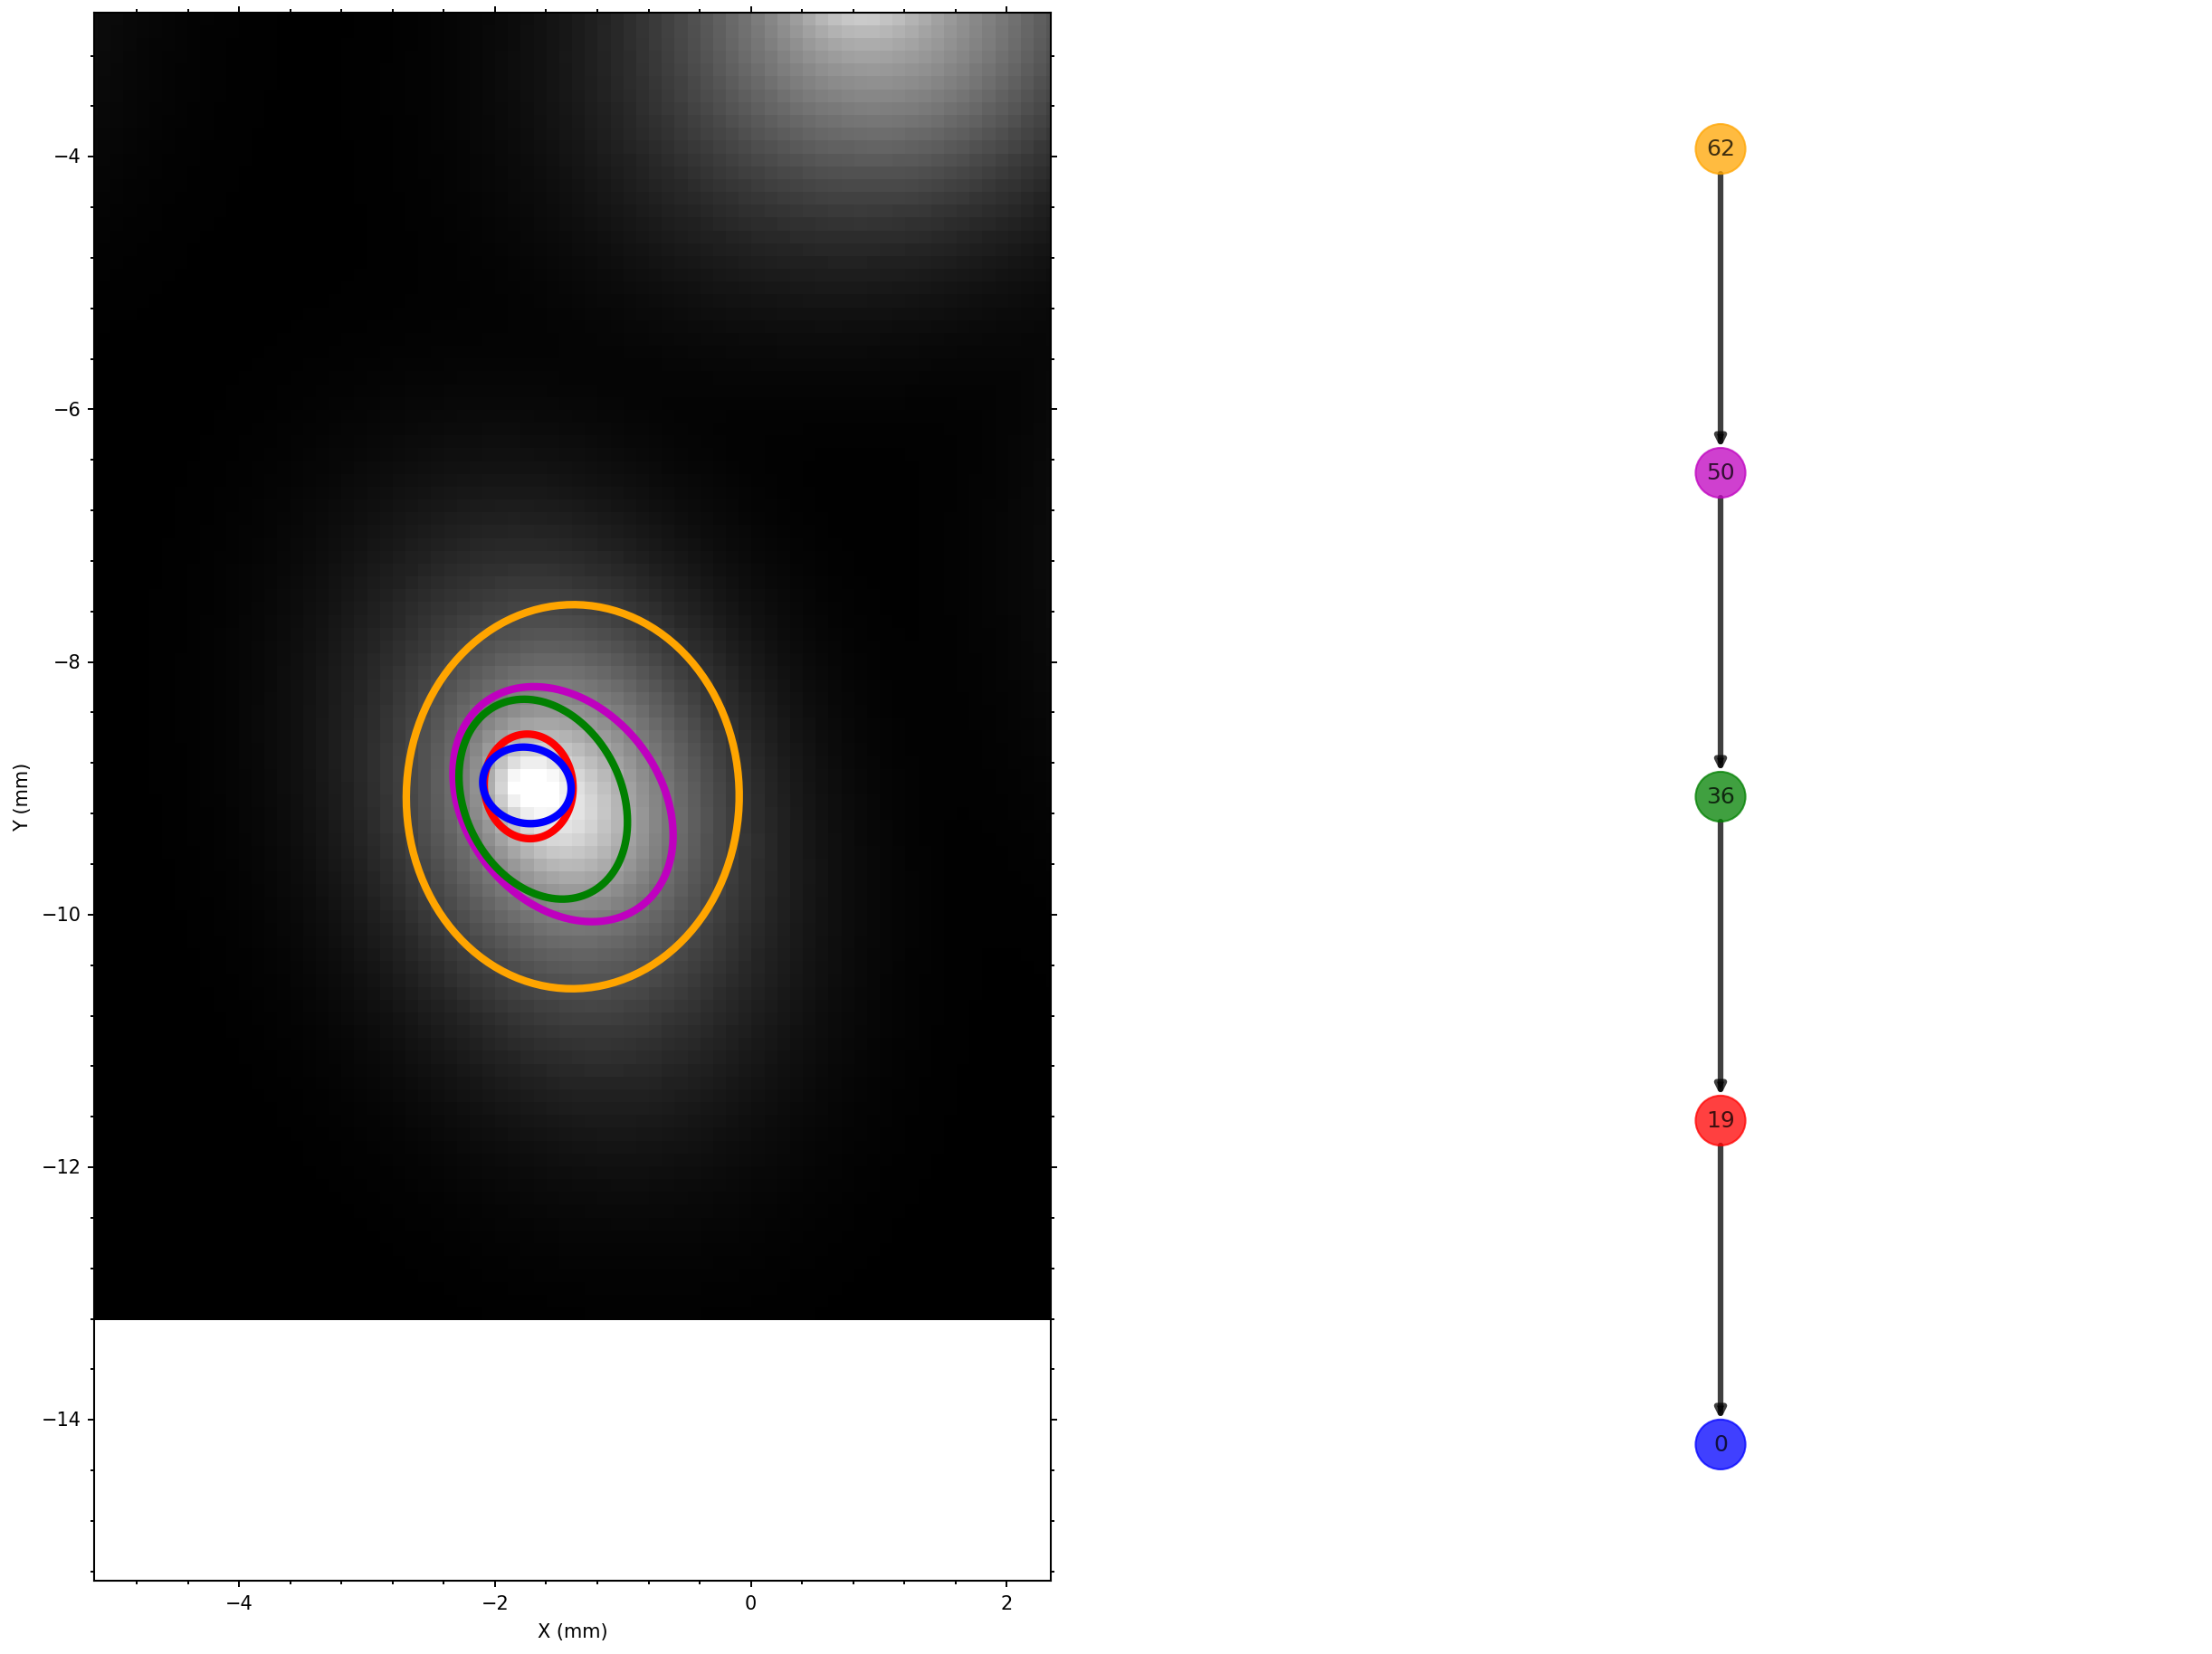

In [14]:
image = dataset[-1].fits_img
fig = network.structures[0].plot(image)

In [16]:
network.data

(<analysis.analyse.Data at 0x27a4bcce4b0>,
 <analysis.analyse.Data at 0x27a3ab2b860>)

In [29]:
plotter.InspectNetwork(network)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


INFO: Auto-setting vmin to  2.434e-33 [aplpy.core]
INFO: Auto-setting vmax to  4.696e+01 [aplpy.core]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


0
seen component number 0
recentering in (np.float64(-1.3921987639381195), np.float64(-9.066496131017153)) at radius 3.739519243446702


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


...

2
seen component number 2
recentering in (np.float64(4.353962354265815), np.float64(-1.1909417633528885)) at radius 3.927503748515927


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


3
seen component number 3
recentering in (np.float64(7.061455098685345), np.float64(-4.891409987767492)) at radius 3.8971369459847987


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


4
seen component number 4
recentering in (np.float64(5.630147345822993), np.float64(-6.706864672507139)) at radius 3.663818201119056


# Plot all the maps

In [33]:
from analysis import image_utility as iu
import aplpy
from astropy.io import fits

####### Figures Definition
FIGURE = plt.figure(figsize=(16, 16.6))

####### ___________________

dxx = 1/3
dyy = 0.45

subplots_coords = [
    [- 1/20, 0.5, dxx, dyy], # PACS 70 # 1/3
    [1/3 - 1/20, 0.5, dxx, dyy], # PACS 160 # 2/3
    [0, 0, dxx, dyy], # SPIRE 250
    [1/3, 0, dxx, dyy], # SPIRE 350
    [2/3, 0, dxx, dyy], # SPIRE 500
    
]

colors = ["m", "g", "b", "r", "c"][::-1]
lab = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for data, subplot, color, label in zip(dataset[1:], subplots_coords, colors, lab):
    img, hdr = iu.OpenImage(data.fits_img, path=True)
    img[img == 0] = np.nan
    new_fits = fits.PrimaryHDU(data=img, header=hdr)
    
    if data.beam < 15:
        vmin = 10
        vmax = 200_000
    else:
        vmin = 10
        vmax = 20_000

    fig = aplpy.FITSFigure(new_fits, figure=FIGURE, subplot=subplot)
    
    #stretch : { ‘linear’, ‘log’, ‘sqrt’, ‘arcsinh’, ‘power’ }
    fig.show_colorscale(cmap='Greys', vmin=vmin, vmax=vmax, stretch='log') 
    #fig.show_grayscale(vmin=vmin, vmax=vmax, stretch='log') 
    
    fig.add_colorbar()
    fig.colorbar.set_font(size=12)
    fig.colorbar.set_axis_label_font(size=16)
    fig.colorbar.hide()
    
    if (data.beam == 13.5) or (data.beam == 36.3):
        #fig.add_colorbar()
        ticks = 10**np.arange(np.log10(vmin), np.log10(vmax))
        #print(ticks)
        fig.colorbar.show(log_format=True)
        fig.colorbar.set_ticks(ticks)
        fig.colorbar.set_axis_label_text("MJy/sr")
        fig.colorbar.set_font(size=18)

    ### AXES
    fig.tick_labels.set_xformat('dd.ddd')
    fig.tick_labels.set_yformat('dd.ddd')
    fig.tick_labels.set_font(size=16)
    
    fig.tick_labels.hide_y()
    fig.axis_labels.hide()
    
    if (data.beam == 24.9):
        fig.axis_labels.set_xtext('RA - J2000')
        fig.axis_labels.set_font(size=18)
        
        fig.axis_labels.show_x()
        
    if (data.beam == 8.4) or (data.beam == 18.2):
        fig.axis_labels.set_ytext('DEC - J2000')
        fig.axis_labels.set_font(size=18)
        
        fig.axis_labels.show_y()
        fig.tick_labels.show_y()
        
    ### beam print
            
    #fig._header["BMAJ"] = data.beam
    #fig._header["BMIN"] = data.beam
    #fig._header["BPA"] = 0
    #fig.add_beam()
    #fig.beam.set_major(data.beam / 3600)
    #fig.beam.set_minor(data.beam / 3600)
    #fig.beam.set_color('red')
    #fig.beam.set_hatch('+')
    
    ### LABELS
    wave = int(data.metadata.get('wavelength'))
    if wave < 200:
        instrument = "PACS"
    else:
        instrument = "SPIRE"
        
    fig.add_label(0.1, 0.05, f'{instrument} \n {wave}$\mu m$', relative=True, style="oblique", size=20,
                 color=color, weight="book")
    fig.add_label(0.1, 0.95, label, relative=True, size=24, color="k", weight="bold")
    
    #np.round(data.metadata.get('wavelength'))
    ###grid
    ### PROPS
    fig.add_grid()
    fig.grid.set_color('white')
    fig.grid.set_alpha(0.5)
    fig.grid.set_linestyle('solid')
    fig.grid.set_xspacing(0.3)
    fig.grid.set_yspacing(0.3)
    
    ### CLUMPS
    P = clumps["_Polygon"][clumps["_phlevel"] == data.beam]

    PTS = [] #idx in original 739
    for n, p in zip(P.index, P):
        x, y = p.exterior.xy
        PTS.append(np.reshape(np.ravel([x, y]), (len(x), 2), order='F'))
        
    fig.show_polygons(PTS, facecolor="none", edgecolor=color, lw=1)
    
    ### REGIONS
    #labelsxy = ["S Mon", "IRAS 1", "IRAS 2", "Nébuleuse \ndu Cône"]
    labelsxy = ["S Mon", "NGC 2264-C", "NGC 2264-D", "Nébuleuse \ndu Cône"]
    #xw = [100.243965051400, 100.2923281046300 , 100.26171500, 100.3]#100.243965051400
    #yw = [9.8950673580600, 9.4926764500400, 9.60449200, 9.4]#9.8950673580600
    xw = [100.243965051400, 100.29 , 100.27, 100.3]#100.243965051400
    yw = [9.8950673580600, 9.49, 9.58, 9.4]#9.8950673580600

    dxw = [-0.02, -0.12, -0.07, 0]
    dyw = [0.02, -0.09, 0.03, -0.13]

    #fig.show_markers(xw[:-1], yw[:-1], coords_frame='world', marker="*", s=40, alpha=0.5)
    
    #for lab, xxw, yyw, dx, dy in zip(labelsxy, xw, yw, dxw, dyw):
    #    fig.add_label(xxw+dx, yyw+dy, lab, size=14, weight='bold')
    
    #fig.show_circles(xw[-1], yw[-1], 0.05, coords_frame='world')
    fig.show_ellipses(xw[-3], yw[-3], 0.05, 0.075, angle=30+90, coords_frame='world')
    fig.show_ellipses(xw[-2], yw[-2], 0.09, 0.095, angle=90, coords_frame='world')

    fig.show_rectangles(xw[-1], yw[-1], 0.05, 0.075, angle=30, coords_frame='world')
    
    ### NORTH
    arrow_north = (99.652, 9.471, 0.150, 0)
    x, y, dx, dy = arrow_north
    fig.show_arrows(x, y, dy, dx, facecolor="white", ec="k", width=15)
    #fig.add_label(0.92, 0.95, f'Nord', relative=True, style="normal", size=14,
    #              color="black", weight="bold")
    
    fig.add_scalebar(1)
    fig.scalebar.set_length(206264 / 3600 / 723)
    fig.scalebar.set_corner('bottom right')
    fig.scalebar.set_label('1 pc')

    fig.scalebar.set_font(size=14, weight='bold')

    fig.scalebar.set_linewidth(4)
    fig.scalebar.set(linestyle='solid', color='k')
    
    
file = "/Users/thomaben/Documents/Working/TestApp/NGC2264/Data/densmap/hi.surface.density.r18p2.bor.fits"

img, hdr = iu.OpenImage(file, path=True)
#img[img == 0] = np.nan
new_fits = fits.PrimaryHDU(data=img, header=hdr)

subplot = [2/3 + 1/20, 0.5, dxx, dyy] # Colonne densité
vmin = 1e21
vmax = 5e23
    
fig = aplpy.FITSFigure(new_fits, figure=FIGURE, subplot=subplot)

### REGIONS
#labelsxy = ["S Mon", "IRAS 1", "IRAS 2", "Nébuleuse \ndu Cône"]
labelsxy = ["S Mon", "NGC 2264-C", "NGC 2264-D", "Nébuleuse \ndu Cône"]
#xw = [100.243965051400, 100.2923281046300 , 100.26171500, 100.3]#100.243965051400
#yw = [9.8950673580600, 9.4926764500400, 9.60449200, 9.4]#9.8950673580600
xw = [100.243965051400, 100.29 , 100.27, 100.3]#100.243965051400
yw = [9.8950673580600, 9.49, 9.58, 9.4]#9.8950673580600

dxw = [-0.02, -0.12, -0.07, 0]
dyw = [0.02, -0.09, 0.03, -0.13]

fig.show_markers(xw[0], yw[0], coords_frame='world', marker="*", s=40, alpha=0.5)

for lab, xxw, yyw, dx, dy in zip(labelsxy, xw, yw, dxw, dyw):
    fig.add_label(xxw+dx, yyw+dy, lab, size=14, weight='bold')

#fig.show_circles(xw[-1], yw[-1], 0.05, coords_frame='world')
fig.show_ellipses(xw[-3], yw[-3], 0.05, 0.075, angle=30+90, coords_frame='world')
fig.show_ellipses(xw[-2], yw[-2], 0.09, 0.095, angle=90, coords_frame='world')

fig.show_rectangles(xw[-1], yw[-1], 0.05, 0.075, angle=30, coords_frame='world')

### NORTH
arrow_north = (99.665, 9.471, 0.150, 0)
x, y, dx, dy = arrow_north
fig.show_arrows(x, y, dy, dx, facecolor="white", ec="k", width=15)
fig.add_label(0.92, 0.95, f'Nord', relative=True, style="normal", size=16,
              color="black", weight="bold")

#stretch : { ‘linear’, ‘log’, ‘sqrt’, ‘arcsinh’, ‘power’ }
fig.show_colorscale(cmap='Greys', vmin=vmin, vmax=vmax, stretch='log') 
#fig.show_grayscale(vmin=vmin, vmax=vmax, stretch='log') 

fig.add_label(0.1, 0.95, '(o)', relative=True, size=24, color="k", weight="bold")

fig.add_colorbar()
fig.colorbar.set_font(size=12)
fig.colorbar.set_axis_label_font(size=16)

ticks = 10**np.arange(np.log10(vmin), np.log10(vmax)+1)
#print(ticks)
fig.colorbar.show(log_format=True)
fig.colorbar.set_ticks(ticks)
fig.colorbar.set_axis_label_text("$H_2 / cm^2$")
fig.colorbar.set_font(size=18)

fig.tick_labels.set_xformat('dd.ddd')
fig.tick_labels.set_yformat('dd.ddd')
fig.tick_labels.set_font(size=16)

fig.add_grid()
fig.grid.set_color('white')
fig.grid.set_alpha(0.5)
fig.grid.set_linestyle('solid')
fig.grid.set_xspacing(0.3)
fig.grid.set_yspacing(0.3)

#fig.tick_labels.hide_y()
fig.axis_labels.hide()

X = [x for classe, x in zip(dataset[0].catalog["Class"], dataset[0].catalog["_RAJ2000"]) 
     if classe == "0/I  "]
Y = [x for classe, x in zip(dataset[0].catalog["Class"], dataset[0].catalog["_DEJ2000"]) 
     if classe == "0/I  "]

fig.show_markers(X, Y, facecolor="white", edgecolor="k", alpha=1, marker="X", lw=1, s=40)
        

fig.add_label(0.5, 0.075, u'Carte de \ndensité de colonne \nde résolution 18.2"', relative=True, style="oblique", size=16,
              color="k", weight="book")

fig.add_scalebar(1)
fig.scalebar.set_length(206264 / 3600 / 723)
fig.scalebar.set_corner('bottom right')
fig.scalebar.set_label('1 pc')

fig.scalebar.set_font(size=14, weight='bold')

fig.scalebar.set_linewidth(4)
fig.scalebar.set(linestyle='solid', color='k')

<>:95: SyntaxWarning: invalid escape sequence '\m'
<>:95: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Benjamin\AppData\Local\Temp\ipykernel_8632\424517447.py:95: SyntaxWarning: invalid escape sequence '\m'
  fig.add_label(0.1, 0.05, f'{instrument} \n {wave}$\mu m$', relative=True, style="oblique", size=20,
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


AttributeError: 'ScalarFormatterLocator' object has no attribute '_precision'

AttributeError: 'ScalarFormatterLocator' object has no attribute '_precision'

<Figure size 2400x2490 with 1 Axes>

In [ ]:
import aplpy
from astropy.io import fits

####### Figures Definition
FIGURE = plt.figure(figsize=(16, 16))

dxx = 1/3
dyy = 0.47

subplots_coords = [
    [0, 0, dxx, dyy], # PACS 70 # 1/3
    [1/3, 0, dxx, dyy], # PACS 160 # 2/3
    [2/3, 0, dxx, dyy], # SPIRE 250
    
]

vmin = 1e21
vmax = 5e23

dh = 0.001
ellipses = [
    (100.314022, 9.472929, 0.024794+dh, 0.018344+dh, -30), #63.730345
    (100.278454, 9.582341, 0.028636+dh, 0.020705+dh, -30), #80.888282
    (100.211803, 9.585481, 0.016697+dh, 0.004039+dh, -81), #122.306462
    (100.237678, 9.603825, 0.015486+dh, 0.007880+dh, -90) #133.661080
] # class 0/I cluster

xw = [ell[0] for ell in ellipses]
yw = [ell[1] for ell in ellipses]
width = [ell[2]*2 for ell in ellipses]
height = [ell[3]*2 for ell in ellipses]
angle = [ell[4] for ell in ellipses]

colors = ["m", "g", "b", "r", "c"][::-1]
file = "/Users/thomaben/Documents/Working/TestApp/NGC2264/Data/densmap/hi.surface.density.r18p2.bor.fits"

img, hdr = iu.OpenImage(file, path=True)
new_fits = fits.PrimaryHDU(data=img, header=hdr)

for idx, subplot in enumerate(subplots_coords):

    fig = aplpy.FITSFigure(new_fits, figure=FIGURE, subplot=subplot)

    #stretch : { ‘linear’, ‘log’, ‘sqrt’, ‘arcsinh’, ‘power’ }
    fig.show_colorscale(cmap='Greys', vmin=vmin, vmax=vmax, stretch='log') 
    #fig.show_grayscale(vmin=vmin, vmax=vmax, stretch='log') 

    fig.add_colorbar()
    fig.colorbar.set_font(size=12)
    fig.colorbar.set_axis_label_font(size=16)
    fig.colorbar.hide()
    
    if idx == 2:
        ticks = 10**np.arange(np.log10(vmin), np.log10(vmax))
        #print(ticks)
        fig.colorbar.show(log_format=True)
        fig.colorbar.set_ticks(ticks)
        fig.colorbar.set_axis_label_text("$H_2 / cm^2$")
        fig.colorbar.set_font(size=18)

    fig.tick_labels.set_xformat('dd.ddd')
    fig.tick_labels.set_yformat('dd.ddd')
    fig.tick_labels.set_font(size=16)
    
    fig.tick_labels.hide_y()
    fig.axis_labels.hide()
    
    if (idx == 1):
        fig.axis_labels.set_xtext('RAJ2000')
        fig.axis_labels.set_font(size=18)
        
        fig.axis_labels.show_x()
        
    if (idx == 0):
        fig.axis_labels.set_ytext('DEJ2000')
        fig.axis_labels.set_font(size=18)
        
        fig.axis_labels.show_y()
        fig.tick_labels.show_y()

    ###grid
    #fig.add_grid()
    #fig.grid.set_color('white')
    #fig.grid.set_alpha(0.5)
    #fig.grid.set_linestyle('solid')
    #fig.grid.set_xspacing(0.3)
    #fig.grid.set_yspacing(0.3)

    if idx in (1, 2):
        # structures
        modes = ['ISOLATED', 'LINEAR', 'HIERARCHICAL']
        colors = ['k',  'r', '#069AF3'] #= azure
        hatches = ['----', '||||||', '///////']
        alphas = [0.2, 0.2, 0.2]

        for mode, color, hatch, alpha in zip(modes, colors, hatches, alphas):
            polygons = structure_table["polygon"][structure_table["mode"] == mode]

            PTS = []
            for poly in polygons:
                x, y = poly.exterior.xy
                PTS.append(np.reshape(np.ravel([x, y]), (len(x), 2), order='F'))

            fig.show_polygons(PTS, facecolor=color, edgecolor="none", alpha=alpha)
            fig.show_polygons(PTS, facecolor="none", edgecolor=color, hatch=hatch)
            #fig.show_polygons(PTS, facecolor="none", edgecolor=color, alpha=0.7)

    # YSOs
    if idx in (2,):
        X = [x for classe, x in zip(dataset[0].catalog["Class"], dataset[0].catalog["_RAJ2000"]) 
             if classe == "0/I  "]
        Y = [x for classe, x in zip(dataset[0].catalog["Class"], dataset[0].catalog["_DEJ2000"]) 
             if classe == "0/I  "]

        fig.show_markers(X, Y, facecolor="white", edgecolor="k", alpha=1, marker="X", lw=0.5, s=40)
    
    if idx == 0:
        hierarchical_structures = structure_table.loc[structure_table["mode"] == "HIERARCHICAL", "component"]
        hierarchical_structures[~hierarchical_structures.index.isin(hierarchical_structures.index[suspicious])]

        to_consider = structure_table[~structure_table.index.isin(hierarchical_structures.index[suspicious])]
        to_consider.index = np.arange(0, len(to_consider))
        
        to_notconsider = structure_table[structure_table.index.isin(hierarchical_structures.index[suspicious])]
        to_notconsider.index = np.arange(0, len(to_notconsider))
        
        modes = ['ISOLATED', 'LINEAR', 'HIERARCHICAL']
        colors = ['k',  'r', '#069AF3'] #= azure
        hatches = ['----', '||||||', '///////']
        alphas = [0.2, 0.2, 0.2]

        for mode, color, hatch, alpha in zip(modes, colors, hatches, alphas):
            if mode == 'HIERARCHICAL':
                polygons = to_consider["polygon"][to_consider["mode"] == mode]

                PTS = []
                for poly in polygons:
                    x, y = poly.exterior.xy
                    PTS.append(np.reshape(np.ravel([x, y]), (len(x), 2), order='F'))

                fig.show_polygons(PTS, facecolor=color, edgecolor="none", alpha=alpha)
                fig.show_polygons(PTS, facecolor="none", edgecolor=color, hatch=hatch)
                
                polygons = to_notconsider["polygon"][to_notconsider["mode"] == mode]

                PTS = []
                for poly in polygons:
                    x, y = poly.exterior.xy
                    PTS.append(np.reshape(np.ravel([x, y]), (len(x), 2), order='F'))

                color = "g"
                fig.show_polygons(PTS, facecolor=color, edgecolor="none", alpha=alpha)
                fig.show_polygons(PTS, facecolor="none", edgecolor=color)
                
                #polygons = population.table["polygon"][population.table["mode"] == mode]
            else:
                polygons = structure_table["polygon"][structure_table["mode"] == mode]

                PTS = []
                for poly in polygons:
                    x, y = poly.exterior.xy
                    PTS.append(np.reshape(np.ravel([x, y]), (len(x), 2), order='F'))

                fig.show_polygons(PTS, facecolor=color, edgecolor="none", alpha=alpha)
                fig.show_polygons(PTS, facecolor="none", edgecolor=color, hatch=hatch)
            
            
            #fig.show_polygons(PTS, facecolor="none", edgecolor=color, alpha=0.7)

            
        #fig.show_ellipses(xw, yw, width, height, angle=angle, edgecolor="b", lw=2)
    
    arrow_north = (99.652, 9.471, 0.150, 0)
    x, y, dx, dy = arrow_north
    fig.show_arrows(x, y, dy, dx, facecolor="white", ec="k", width=15)
    
    fig.add_grid()
    fig.grid.set_color('white')
    fig.grid.set_alpha(0.5)
    fig.grid.set_linestyle('solid')
    fig.grid.set_xspacing(0.3)
    fig.grid.set_yspacing(0.3)
#fig.scalebar.show()  # length in degrees

# Distribution of pixels in structures

In [ ]:
file = "/Users/thomaben/Documents/Working/TestApp/NGC2264/Data/densmap/hi.surface.density.r18p2.bor.fits"

# fig = plots.plotStackedPix(population.table, file, patterns=['///', '|||', '---'], norm=True)
patterns=['///', '|||', '---']
N, H, L, I, HL, LI, HI, bins = iu.pixelBins(structure_table, file, norm=True)

fig = plt.figure(figsize=(10, 10), dpi=100)
ax = fig.add_subplot(111)

barWidth = np.diff(bins)
x = (bins[:-1] + bins[1:]) / 2

for i, xi in enumerate(x):
    if N[i] == 0:
        ax.bar(xi, 1, color='grey', edgecolor='grey', width=barWidth[i], align="edge", **kwargs)

#print(H, L, I)
H = np.nan_to_num(H)
L = np.nan_to_num(L)
I = np.nan_to_num(I)
HL = np.nan_to_num(HL)
LI = np.nan_to_num(LI)
HI = np.nan_to_num(HI)

def axbar(x, y, patterns, colors, **kwargs):
    ax.bar(x, y, color=colors, **kwargs)
    ax.bar(x, y, color='none', edgecolor="w", hatch=patterns, **kwargs)
    ax.bar(x, y, color='none', edgecolor=colors, **kwargs)

### draw single
axbar(x, H, patterns=patterns[0], colors='b', bottom=HI, width=barWidth, align="edge", label=u"Hierarchical")
axbar(x, L, patterns=patterns[1], colors='r', bottom=H + HI + HL, width=barWidth, align="edge", label=u"Linear")
axbar(x, I, patterns=patterns[2], colors='k', bottom=H + HI + HL + L + LI, width=barWidth, align="edge",
      label=u"Isolated")

### draw primary color
axbar(x, HI, patterns=patterns[0], colors='b', width=barWidth, align="edge")
axbar(x, HL, patterns=patterns[0], colors='b', bottom=H + HI, width=barWidth, align="edge")
axbar(x, LI, patterns=patterns[1], colors='r', bottom=H + HI + HL + L, width=barWidth, align="edge")

lw = 3
txtline = x[min(np.argwhere(H > 0.9))]
ax.axvline(txtline, ls="--", color="k", lw=lw)
props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax.text(txtline*1.2, 0.8, "> 90%", rotation=90, fontsize=14, bbox=props)
print("Density exclusive : ", txtline, " at ", 0.95, " of Hierarchical")

txtline = x[min(np.argwhere(H > 0.5)) - 1]
ax.axvline(txtline, ls="--", color="k", lw=lw)
ax.text(txtline/1.5, 0.8, "> 50%", rotation=90, fontsize=14)
print("Density dominant : ", txtline, " at ", 0.4, " of Hierarchical")

plt.axhline(1, color="k")
    
ax.set_xlim(x[0], x[-1])
ax.set_xlabel("Column density $[H_2/cm^2]$", fontsize=22)
ax.set_ylabel("Structure area/total \n per bin of density", fontsize=22)

ax.tick_params(which='major', axis='both', size=5)
ax.tick_params(which='minor', axis='both', size=3)
ax.tick_params(axis='both', labelsize=16)

ax.set_xscale('log')

# Plot networks

In [ ]:
import pandas as pd
import shapely.geometry as shp
from tqdm import tqdm
import networkx as nx
from astropy.io import fits

file = "/Users/thomaben/Documents/Working/TestApp/NGC2264/Data/densmap/hi.surface.density.r18p2.bor.fits"

polygons = structure_table["polygon"][structure_table["mode"] == "HIERARCHICAL"]
Radius = [np.sqrt(poly.area/np.pi)*3 for poly in polygons]

hierarchical_structures = structure_table["component"][structure_table["mode"] == "HIERARCHICAL"]
xposition = structure_table["xposition"][structure_table["mode"] == "HIERARCHICAL"]
yposition = structure_table["yposition"][structure_table["mode"] == "HIERARCHICAL"]

figure, axs = plt.subplots(nrows=6, ncols=4, figsize=(20, 30), dpi=300)
axs_flat = np.ravel(axs)

img, hdr = iu.OpenImage(file, path=True)
img[img > 0] = np.nan
new_fits = fits.PrimaryHDU(data=img, header=hdr)

vmin = 1e20
vmax = 1e23

colors = ["m", "g", "b", "r", "c"][::-1]
scales = [d.beam for d in network.data]
colors = {str(scale):color for color, scale in zip(colors, scales[1:])}
suspicious = np.array([1, 2, 3, 10, 11, 17, 18, 20, 22]) - 1

for ax in axs_flat:
    ax.axis('off')

for label, (radius, struct, ax, xp, yp) in tqdm(enumerate(zip(Radius, hierarchical_structures, axs_flat, xposition, yposition))):

    if label < 50:
        #print(ax._position.bounds)
        if label+1 in (5, 6, 16, 23):
            xp = xp - 0.01
            yp = yp - 0.01

        elif label+1==8:
            xp = xp - 0.
            yp = yp - 0.01

        elif label+1==9:
            xp = xp - 0.001
            yp = yp - 0.015

        elif label+1==12:
            xp = xp + 0.005
            yp = yp - 0.

        elif label+1==15:

            xp = xp - 0.01
            yp = yp - 0.01
            radius = radius * 1.5

        elif label+1==17:
            xp = xp + 0.005
            yp = yp + 0.003

        fig = aplpy.FITSFigure(new_fits, figure=figure, subplot=list(ax._position.bounds))

        fig.recenter(xp-0.01, yp-0.01, radius=radius)

        fig.show_colorscale(cmap='Greys', vmin=vmin, vmax=vmax, stretch='log') 
        
        fig.ticks.hide()
        fig.tick_labels.hide()
        fig.axis_labels.hide()

        for i, b in enumerate(sorted(scales, reverse=True)):
            P = [poly for node, poly in struct.nodes('_Polygon') if struct.nodes[node]["_phlevel"] == b]

            if b != 2.0:
                PTS = []
                for poly in P:
                    x, y = poly.exterior.xy
                    PTS.append(np.reshape(np.ravel([x, y]), (len(x), 2), order='F'))

                fig.show_polygons(PTS, facecolor="None", edgecolor=colors[str(b)], lw=2, alpha=1)

            elif len(P) != 0:
                X = [poly.centroid.x for poly in P]
                Y = [poly.centroid.y for poly in P]

                fig.show_markers(X, Y, facecolor="white", edgecolor="k", alpha=1, marker="X", lw=1, s=60)

        #arrow_north = (99.652, 9.471, 0.150, 0)
        #x, y, dx, dy = arrow_north
        #fig.show_arrows(x, y, dy, dx, facecolor="white", ec="k", width=15)

        color = []
        for _, b in struct.nodes("_phlevel"):
            if b != 2.:
                color.append(colors[str(b)])
            else:
                color.append("k")

        coords = list(ax._position.bounds)
        dx = coords[2]
        coords[2] = dx * 3/5
        coords[0] = coords[0] + dx * 2/5
        net_ax = plt.axes(coords)

        pos = nx.multipartite_layout(struct, subset_key="_level", align="horizontal")
        nx.draw(struct, pos, ax=net_ax, node_color=color, node_size=200, with_labels=False)

        #net_ax.axis("equal")
        net_ax.axis('off')

        if label in suspicious:
            net_ax.text(- 0.5, 0.9, str(label+1)+" - ?", transform=net_ax.transAxes,
                    fontsize=16, fontweight='bold', va='top')
        else:
            net_ax.text(- 0.5, 0.9, label+1, transform=net_ax.transAxes,
                    fontsize=16, fontweight='bold', va='top')

        dAU = 20e3
        dpc = 723
        
        fig.add_scalebar(dAU/dpc / 3600)
        fig.scalebar.set_corner('bottom left')
        fig.scalebar.set_frame(False)
        fig.scalebar.set_color('black')
        fig.scalebar.set_linewidth(3)  # points

        if label == 0:
            fig.scalebar.set_label("20kAU")
            fig.scalebar.set_font_size(14)
    
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# Fractalité et N vs R

In [ ]:
fractal = []

fractal_160conv = []
fractal_geom = []

fractal_corr = []
missed_corr = []


idx = 0
for s in network.structures:
    if s.mode.name == "HIERARCHICAL":
        if idx not in suspicious:
            fractal_corr.append(s.fractality)
            missed_corr.append(s.percmissed)
        fractal.append(s.fractality)
        idx += 1
        
_, bins, _ = plt.hist(fractal, bins=10, density=True, edgecolor="b", histtype='stepfilled',fill=False, hatch='/')
plt.hist(fractal_corr, bins=bins, density=True, edgecolor="g", histtype='stepfilled',fill=False, hatch='o')

dx = 0.15
plt.plot([1.45-0.15, 1.45+0.15], [2.8, 2.8], color="b")
plt.plot([1.45-0.15, 1.45-0.15], [2.78, 2.82], color="b")
plt.plot([1.45+0.15, 1.45+0.15], [2.78, 2.82], color="b")


fract_0 = 1.6
dfract_0 = 0.3
plt.plot([fract_0 - dfract_0, fract_0 + dfract_0], [3, 3], color="g")
plt.plot([fract_0 - dfract_0, fract_0 - dfract_0], [2.98, 3.02], color="g")
plt.plot([fract_0 + dfract_0, fract_0 + dfract_0], [2.98, 3.02], color="g")

plt.xlabel("Fractalité $\mathcal{F}$")
plt.ylabel("Distribution normalisée")

plt.ylim([0, 3.1])

print("mean", np.mean(fractal), "; corr = ", np.mean(fractal_corr))
print("median", np.median(fractal), "; corr = ", np.median(fractal_corr))
print("maxmissed", np.max(missed_corr))

fractality_corr_carences = ( np.median(fractal_corr) * (1+0.2) + np.median(fractal))/2
dfractality_corr_carences = fractality_corr_carences - np.median(fractal)

print("carences corr = ", fractality_corr_carences, "+/-", dfractality_corr_carences)

phi2D = np.log(fractality_corr_carences) / np.log(2)
dphi2D = dfractality_corr_carences / fractality_corr_carences

print("phi2D = ", phi2D, "+/-", dphi2D)


f = -0.3
df = 0.05

d1 = (dphi2D/(1 + f))**2
d2 = (phi2D / (1 + f)**2 * df) **2

phi3D, dphi3D = phi2D / (1 + f), np.sqrt(d1 + d2)

print("phi3D = ", phi3D, "+/-", dphi3D)

In [ ]:
distance = network.data[-1].distance
x, meany, stdy = plotter.getFragCurve(network, distance, mode = "HIERARCHICAL")

print("mean prod. y axis =", meany)

fig, ax = plt.subplots()

x_kau = x / 1000
ax.errorbar(x_kau, meany, stdy, np.zeros_like(x), "o")

fractality = np.mean(1.33)
fractality_arr = np.ones_like(x) * fractality
exponent = -(np.log(fractality_arr)/np.log(2))

ax.plot(x_kau, (x / max(x))**exponent, "-", color="grey")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("R [kAU]")
ax.set_ylabel("$<N_{tot}/N_{tot}^0>$")

# Uncertainties with virtual nodes

In [ ]:
fractal = []
missed = []

for s in network.structures:
    if s.mode.name == "HIERARCHICAL":
        missed.append(s.percmissed)
        fractal.append(s.fractality)

raw_interval = (np.median(fractal), 

error_from_missed = 

fractality_corr_carences = ( np.median(fractal_corr) * (1+0.2) + np.median(fractal))/2
dfractality_corr_carences = fractality_corr_carences - np.median(fractal)

print("carences corr = ", fractality_corr_carences, "+/-", dfractality_corr_carences)

phi2D = np.log(fractality_corr_carences) / np.log(2)
dphi2D = dfractality_corr_carences / fractality_corr_carences

print("phi2D = ", phi2D, "+/-", dphi2D)


projection_error = -0.3
dprojection_error = 0.05

d1 = (dphi2D/(1 + projection_error))**2
d2 = (phi2D / (1 + projection_error)**2 * dprojection_error) **2

phi3D, dphi3D = phi2D / (1 + f), np.sqrt(d1 + d2)

print("phi3D = ", phi3D, "+/-", dphi3D)

In [ ]:
virtual = utility.virtualNodes(network.network, network.levels)

In [ ]:
network_virtualfill = analyse.Network(*network.data, min_overlap=network.min_overlap, graph=virtual)

utility.fractality(network_virtualfill.network)

clumps = utility.toDataFrame(network_virtualfill.network)

network_virtualfill.extractStructures()
structure_table_virtual = network_virtualfill.getStructuresTable()

In [ ]:
plt.hist(structure_table_virtual['fractality'][structure_table_virtual['mode'] == "HIERARCHICAL"], color="b")
plt.hist(structure_table['fractality'][structure_table['mode'] == "HIERARCHICAL"], color="r", alpha=0.5)

print("median with virtual nodes", np.median(structure_table_virtual['fractality'][structure_table_virtual['mode'] == "HIERARCHICAL"]))
print("median without virtual nodes", np.median(structure_table['fractality'][structure_table['mode'] == "HIERARCHICAL"]))

In [ ]:
# Check virtuals

hierarchical_structures = structure_table["component"][structure_table["mode"] == "HIERARCHICAL"]
hierarchical_structures_virtuals = structure_table_virtual["component"][structure_table_virtual["mode"] == "HIERARCHICAL"]

idx = 1
struct = hierarchical_structures.array[idx]
struct_virtual = hierarchical_structures_virtuals.array[idx]

colors = ["m", "g", "b", "r", "c"][::-1]
scales = network.levels
colors = {str(scale):color for color, scale in zip(colors, scales[1:])}

color = []
for _, b in struct.nodes("_phlevel"):
    if b != 2.:
        color.append(colors[str(b)])
    else:
        color.append("grey")

color_virtual = []
for node, b in struct_virtual.nodes("_phlevel"):
    if b != 2. and struct_virtual.nodes[node]["_Kind"].name != "VIRTUAL":
        color_virtual.append(colors[str(b)])
    elif b ==2:
        color_virtual.append("k")
    else:
        color_virtual.append("grey")
                
figure, axs = plt.subplots(ncols=2, figsize=(5, 5))

# without virtuals
pos = nx.multipartite_layout(struct, subset_key="_level", align="horizontal")
nx.draw(struct, pos, ax=axs[0], node_color=color, node_size=200, with_labels=True)

# with virtuals
pos = nx.multipartite_layout(struct_virtual, subset_key="_level", align="horizontal")
nx.draw(struct_virtual, pos, ax=axs[1], node_color=color_virtual, node_size=200, with_labels=False)

In [ ]:
def fragmentation_rate2D(fractality, uncertainty):
    return np.log(fractality)/np.log(2), uncertainty/fractality/np.log(2)

for structure_real, structure_hole in zip(network.structures, network_virtualfill.structures):

    fractality = (structure_real.fractality + structure_hole.fractality)/2
    uncertainty = abs(structure_real.fractality - structure_hole.fractality)/2
    
    phi, dphi = fragmentation_rate2D(fractality, uncertainty)

    structure_real.fragmentation_rate = phi, dphi
    

In [ ]:
for s in network.structures:
    if s.mode.name == "HIERARCHICAL":
        print(s.fragmentation_rate)

In [10]:
1.85, 1.43, 1.15, 0.98, 0.83

(1.5**4)**1.65, (1.5**5)**1.43, (1.5**6)**1.15, (1.5**7)**0.98, (1.5**8)**0.83

(14.527882202440647,
 18.15735155351506,
 16.407019244004534,
 16.143066548792884,
 14.765425277138457)